<a href="https://colab.research.google.com/github/kjian254416-blip/ML300/blob/main/Chapter_05_%EB%AF%B8%EA%B5%AD%EC%9D%98_%EB%8C%80%ED%86%B5%EB%A0%B9%EC%9D%80_%EC%96%B4%EB%96%BB%EA%B2%8C_%EB%BD%91%ED%9E%90%EA%B9%8C(%EB%AC%B8%EC%A0%9C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 주제 : 미국의 대통령은 어떻게 뽑힐까?
----------

## 실습 가이드
    1. 데이터를 다운로드하여 Colab에 불러옵니다.
    2. 필요한 라이브러리는 모두 코드로 작성되어 있습니다.
    3. 코드는 위에서부터 아래로 순서대로 실행합니다.
    
    
## 데이터 소개
    - 이번 주제는 US Election 2020 데이터셋을 사용합니다.
    
    - 총 11개의 파일 중 정보가 가장 많은 2개의 파일을 사용합니다.
    president_county_candidate.csv: 대통령 투표 결과
    governors_county_candidate.csv: 카운티 지사 투표 결과
    
    - 총 1개의 보조 데이터를 이용합니다.
    acs2017_county_data.csv: 카운티별 인구조사 데이터
    
    - 각 파일의 컬럼은 아래와 같습니다.
    state: 주
    county: 카운티(군)
    district: 지구
    candidate: 후보자
    party: 후보자의 소속 정당
    total_votes: 득표 수
    won: 지역 투표 우승 여부
    
    
    
- 데이터 출처: https://www.kaggle.com/unanimad/us-election-2020
- 보조 데이터: https://www.kaggle.com/muonneutrino/us-census-demographic-data

## 최종 목표
    - 보조 데이터셋을 이용하여 데이터셋 보강하는 방법 이해
    - plotly를 이용한 Choropleth 시각화 방법 이해
    - Regression과 Classification의 차이 이해

- 출제자 : 신제용 강사
---

## Step 0. 데이터에 관한 사전 배경 지식

### 미국의 선거 제도에 대하여


### 2020 미국 선거 데이터셋 설명


### 2017 미국 인구조사 데이터셋(보조 데이터셋) 설명

## Step 1. 데이터셋 준비하기

In [1]:
!pip install geopandas
!pip install pyshp
!pip install shapely
!pip install plotly-geo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 58.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 문제 1. Colab Notebook에 Kaggle API 세팅하기


In [3]:
import os

In [4]:
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기

os.environ['KAGGLE_USERNAME'] = 'kimjian254416'
os.environ['KAGGLE_KEY'] = '0457ef800614319f99e6b8144bfd741e'

### 문제 2. 데이터 다운로드 및 압축 해제하기


In [5]:
# Linux 명령어로 Kaggle API를 이용하여 데이터셋 다운로드하기 (!kaggle ~)
# Linux 명령어로 압축 해제하기


!kaggle datasets download -d unanimad/us-election-2020
!kaggle datasets download -d muonneutrino/us-census-demographic-data
!unzip '*.zip'

Dataset URL: https://www.kaggle.com/datasets/unanimad/us-election-2020
License(s): CC0-1.0
100% 429k/429k [00:00<00:00, 85.9MB/s]

Dataset URL: https://www.kaggle.com/datasets/muonneutrino/us-census-demographic-data
License(s): CC0-1.0
100% 10.6M/10.6M [00:00<00:00, 85.6MB/s]

Archive:  us-census-demographic-data.zip
  inflating: acs2015_census_tract_data.csv  
  inflating: acs2015_county_data.csv  
  inflating: acs2017_census_tract_data.csv  
  inflating: acs2017_county_data.csv  

Archive:  us-election-2020.zip
  inflating: governors_county.csv    
  inflating: governors_county_candidate.csv  
  inflating: governors_state.csv     
  inflating: house_candidate.csv     
  inflating: house_state.csv         
  inflating: president_county.csv    
  inflating: president_county_candidate.csv  
  inflating: president_state.csv     
  inflating: senate_county.csv       
  inflating: senate_county_candidate.csv  
  inflating: senate_state.csv        

2 archives were successfully processed.


### 문제 3. Pandas 라이브러리로 csv파일 읽어들이기


In [6]:
from google.colab import files
uploaded = files.upload()

Saving acs2017_county_data.csv to acs2017_county_data (1).csv


In [7]:
df_census = pd.read_csv('acs2017_county_data.csv')

In [8]:
# from US Election 2020
df_pres = pd.read_csv('president_county_candidate.csv')
df_gov = pd.read_csv('governors_county_candidate.csv')

# from US Census 2017
#df_census = pd.read_csv('acs2017_census_tract_data.csv')

In [9]:
import requests

# State Code 관련 부가 자료 (웹 스크래핑 대신 수동으로 데이터프레임 생성)
state_data = {
    'State': ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'],
    'Postal Code': ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY']
}
state_code= pd.DataFrame(state_data)
state_code.columns = ['State', 'Abbreviation'] # 컬럼명 맞추기

In [10]:
df_pres

,state,county,candidate,party,total_votes,won
0,Delaware,Kent County,Joe Biden,DEM,44552,True
1,Delaware,Kent County,Donald Trump,REP,41009,False
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False
3,Delaware,Kent County,Howie Hawkins,GRN,420,False
4,Delaware,New Castle County,Joe Biden,DEM,195034,True
...,...,...,...,...,...,...
32172,Arizona,Maricopa County,Write-ins,WRI,1331,False
32173,Arizona,Mohave County,Donald Trump,REP,78535,True
32174,Arizona,Mohave County,Joe Biden,DEM,24831,False
32175,Arizona,Mohave County,Jo Jorgensen,LIB,1302,False


## Step 2. EDA 및 데이터 기초 통계 분석


### 문제 4. 각 데이터프레임 구조 및 기초 통계 확인하기


In [11]:
# DataFrame에서 제공하는 메소드를 이용하여 각 데이터프레임의 구조 분석하기 (head(), info(), describe())

df_pres.head()

,state,county,candidate,party,total_votes,won
0,Delaware,Kent County,Joe Biden,DEM,44552,True
1,Delaware,Kent County,Donald Trump,REP,41009,False
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False
3,Delaware,Kent County,Howie Hawkins,GRN,420,False
4,Delaware,New Castle County,Joe Biden,DEM,195034,True


In [12]:
df_pres['candidate'].unique()

array(['Joe Biden', 'Donald Trump', 'Jo Jorgensen', 'Howie Hawkins',
       ' Write-ins', 'Gloria La Riva', 'Brock Pierce',
       'Rocky De La Fuente', 'Don Blankenship', 'Kanye West',
       'Brian Carroll', 'Ricki Sue King', 'Jade Simmons',
       'President Boddie', 'Bill Hammons', 'Tom Hoefling',
       'Alyson Kennedy', 'Jerome Segal', 'Phil Collins',
       ' None of these candidates', 'Sheila Samm Tittle', 'Dario Hunter',
       'Joe McHugh', 'Christopher LaFontaine', 'Keith McCormic',
       'Brooke Paige', 'Gary Swing', 'Richard Duncan', 'Blake Huber',
       'Kyle Kopitke', 'Zachary Scalf', 'Jesse Ventura', 'Connie Gammon',
       'John Richard Myers', 'Mark Charles', 'Princess Jacob-Fambro',
       'Joseph Kishore', 'Jordan Scott'], dtype=object)

In [13]:
df_pres.loc[df_pres['candidate'] =='Kanye West']['total_votes'].sum()

np.int64(66367)

In [14]:
df_pres.loc[df_pres['candidate'] =='Joe Biden']['total_votes'].sum()

np.int64(82046434)

In [15]:
df_gov.head()

,state,county,candidate,party,votes,won
0,Delaware,Kent County,John Carney,DEM,44352,True
1,Delaware,Kent County,Julianne Murray,REP,39332,False
2,Delaware,Kent County,Kathy DeMatteis,IPD,1115,False
3,Delaware,Kent County,John Machurek,LIB,616,False
4,Delaware,New Castle County,John Carney,DEM,191678,True


In [16]:
df_census.head()

,CountyId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001,Alabama,Autauga County,55036,26899,28137,2.7,75.4,18.9,0.3,...,0.6,1.3,2.5,25.8,24112,74.1,20.2,5.6,0.1,5.2
1,1003,Alabama,Baldwin County,203360,99527,103833,4.4,83.1,9.5,0.8,...,0.8,1.1,5.6,27.0,89527,80.7,12.9,6.3,0.1,5.5
2,1005,Alabama,Barbour County,26201,13976,12225,4.2,45.7,47.8,0.2,...,2.2,1.7,1.3,23.4,8878,74.1,19.1,6.5,0.3,12.4
3,1007,Alabama,Bibb County,22580,12251,10329,2.4,74.6,22.0,0.4,...,0.3,1.7,1.5,30.0,8171,76.0,17.4,6.3,0.3,8.2
4,1009,Alabama,Blount County,57667,28490,29177,9.0,87.4,1.5,0.3,...,0.4,0.4,2.1,35.0,21380,83.9,11.9,4.0,0.1,4.9


In [17]:
df_census['County'].value_counts()

,count
County,
Washington County,30
Jefferson County,25
Franklin County,24
Jackson County,23
Lincoln County,23
...,...
Vega Alta Municipio,1
Utuado Municipio,1
Trujillo Alto Municipio,1


In [18]:
state_code.head()

,State,Abbreviation
0,Alabama,AL
1,Alaska,AK
2,Arizona,AZ
3,Arkansas,AR
4,California,CA


In [19]:
df_census['County'].value_counts()

,count
County,
Washington County,30
Jefferson County,25
Franklin County,24
Jackson County,23
Lincoln County,23
...,...
Vega Alta Municipio,1
Utuado Municipio,1
Trujillo Alto Municipio,1


### 문제 5. County 별 통계로 데이터프레임 구조 변경하기


In [35]:
# 모든 데이터프레임의 index를 County로 변경하기

data = df_pres.loc[df_pres['party'].apply(lambda s:str(s) in ['DEM','REP'])]
table_pres = pd.pivot_table(data = data,index=['state','county'],columns='party',values='total_votes')
table_pres.rename({'DEM':'Pres_DEM','REP':'Pres_REP'},axis=1,inplace=True)
table_pres

party                      Pres_DEM  Pres_REP
state   county                               
Alabama Autauga County       7503.0   19838.0
        Baldwin County      24578.0   83544.0
        Barbour County       4816.0    5622.0
        Bibb County          1986.0    7525.0
        Blount County        2640.0   24711.0
...                             ...       ...
Wyoming Sweetwater County    3823.0   12229.0
        Teton County         9848.0    4341.0
        Uinta County         1591.0    7496.0
        Washakie County       651.0    3245.0
        Weston County         360.0    3107.0

[4633 rows x 2 columns]

In [21]:
data = df_gov.loc[df_gov['party'].apply(lambda s: str(s) in ['DEM','REP'])]
table_gov = pd.pivot_table(data = data,index=['state','county'],columns='party',values='votes')
table_gov.rename({'DEM':'Gov_DEM','REP':'Gov_REP'},axis=1,inplace=True)
table_gov

party                             Gov_DEM  Gov_REP
state         county                              
Delaware      Kent County         44352.0  39332.0
              New Castle County  191678.0  82545.0
              Sussex County       56873.0  68435.0
Indiana       Adams County         2143.0   9441.0
              Allen County        53895.0  98406.0
...                                   ...      ...
West Virginia Webster County        659.0   2552.0
              Wetzel County        1727.0   4559.0
              Wirt County           483.0   1947.0
              Wood County          9933.0  26232.0
              Wyoming County       1240.0   6941.0

[1025 rows x 2 columns]

In [22]:
df_census.rename({'State':'state','County':'county'},axis=1,inplace=True)
if 'CountyId' in df_census.columns:
    df_census.drop('CountyId',axis=1,inplace=True)
df_census.set_index(['state','county'],inplace=True)
df_census

TotalPop    Men   Women  Hispanic  White  \
state       county                                                          
Alabama     Autauga County          55036  26899   28137       2.7   75.4   
            Baldwin County         203360  99527  103833       4.4   83.1   
            Barbour County          26201  13976   12225       4.2   45.7   
            Bibb County             22580  12251   10329       2.4   74.6   
            Blount County           57667  28490   29177       9.0   87.4   
...                                   ...    ...     ...       ...    ...   
Puerto Rico Vega Baja Municipio     54754  26269   28485      96.7    3.1   
            Vieques Municipio        8931   4351    4580      95.7    4.0   
            Villalba Municipio      23659  11510   12149      99.7    0.2   
            Yabucoa Municipio       35025  16984   18041      99.9    0.1   
            Yauco Municipio         37585  18052   19533      99.8    0.2   

                                 Black  Native  Asian  Pacific  \
state       county                                               
Alabama     Autauga County        18.9     0.3    0.9      0.0   
            Baldwin County         9.5     0.8    0.7      0.0   
            Barbour County        47.8     0.2    0.6      0.0   
            Bibb County           22.0     0.4    0.0      0.0   
            Blount County          1.5     0.3    0.1      0.0   
...                                ...     ...    ...      ...   
Puerto Rico Vega Baja Municipio    0.1     0.0    0.0      0.0   
            Vieques Municipio      0.0     0.0    0.0      0.0   
            Villalba Municipio     0.1     0.0    0.0      0.0   
            Yabucoa Municipio      0.0     0.0    0.0      0.0   
            Yauco Municipio        0.0     0.0    0.0      0.0   

                                 VotingAgeCitizen  ...  Walk  OtherTransp  \
state       county                                 ...                      
Alabama     Autauga County                  41016  ...   0.6          1.3   
            Baldwin County                 155376  ...   0.8          1.1   
            Barbour County                  20269  ...   2.2          1.7   
            Bibb County                     17662  ...   0.3          1.7   
            Blount County                   42513  ...   0.4          0.4   
...                                           ...  ...   ...          ...   
Puerto Rico Vega Baja Municipio             42838  ...   1.4          0.6   
            Vieques Municipio                7045  ...   5.0          0.0   
            Villalba Municipio              18053  ...   2.1          0.0   
            Yabucoa Municipio               27523  ...   1.4          1.8   
            Yauco Municipio                 29763  ...   1.7          0.1   

                                 WorkAtHome  MeanCommute  Employed  \
state       county                                                   
Alabama     Autauga County              2.5         25.8     24112   
            Baldwin County              5.6         27.0     89527   
            Barbour County              1.3         23.4      8878   
            Bibb County                 1.5         30.0      8171   
            Blount County               2.1         35.0     21380   
...                                     ...          ...       ...   
Puerto Rico Vega Baja Municipio         0.9         31.6     14234   
            Vieques Municipio           1.7         14.9      2927   
            Villalba Municipio          2.8         28.4      6873   
            Yabucoa Municipio           0.1         30.5      7878   
            Yauco Municipio             5.0         24.4      8995   

                                 PrivateWork  PublicWork  SelfEmployed  \
state       county                                                       
Alabama     Autauga County              74.1        20.2           5.6   
            Baldwin County           

In [23]:
df_census.columns

Index(['TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native',
       'Asian', 'Pacific', 'VotingAgeCitizen', 'Income', 'IncomeErr',
       'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'ChildPoverty',
       'Professional', 'Service', 'Office', 'Construction', 'Production',
       'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome',
       'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed',
       'FamilyWork', 'Unemployment'],
      dtype='object')

In [24]:
df_census.drop(['Income', 'IncomeErr','IncomePerCapErr'],axis =1,inplace=True)

성비로 바꿔주기

In [25]:
df_census.drop('Women',axis=1,inplace=True)

In [26]:
df_census['Men']/=df_census['TotalPop']

In [27]:
df_census['VotingAgeCitizen']/=df_census['TotalPop']

In [28]:
df_census['Employed']/=df_census['TotalPop']

In [29]:
df_census.head()

TotalPop       Men  Hispanic  White  Black  Native  \
state   county                                                               
Alabama Autauga County     55036  0.488753       2.7   75.4   18.9     0.3   
        Baldwin County    203360  0.489413       4.4   83.1    9.5     0.8   
        Barbour County     26201  0.533415       4.2   45.7   47.8     0.2   
        Bibb County        22580  0.542560       2.4   74.6   22.0     0.4   
        Blount County      57667  0.494043       9.0   87.4    1.5     0.3   

                        Asian  Pacific  VotingAgeCitizen  IncomePerCap  ...  \
state   county                                                          ...   
Alabama Autauga County    0.9      0.0          0.745258         27824  ...   
        Baldwin County    0.7      0.0          0.764044         29364  ...   
        Barbour County    0.6      0.0          0.773596         17561  ...   
        Bibb County       0.0      0.0          0.782197         20911  ...   
        Blount County     0.1      0.0          0.737215         22021  ...   

                        Walk  OtherTransp  WorkAtHome  MeanCommute  Employed  \
state   county                                                                 
Alabama Autauga County   0.6          1.3         2.5         25.8  0.438113   
        Baldwin County   0.8          1.1         5.6         27.0  0.440239   
        Barbour County   2.2          1.7         1.3         23.4  0.338842   
        Bibb County      0.3          1.7         1.5         30.0  0.361869   
        Blount County    0.4          0.4         2.1         35.0  0.370749   

                        PrivateWork  PublicWork  SelfEmployed  FamilyWork  \
state   county                                                              
Alabama Autauga County         74.1        20.2           5.6         0.1   
        Baldwin County         80.7        12.9           6.3         0.1   
        Barbour County         74.1        19.1           6.5         0.3   
        Bibb County            76.0        17.4           6.3         0.3   
        Blount County          83.9        11.9           4.0         0.1   

                        Unemployment  
state   county                        
Alabama Autauga County           5.2  
        Baldwin County           5.5  
        Barbour County          12.4  
        Bibb County              8.2  
        Blount County            4.9  

[5 rows x 30 columns]

### 문제 6. 여러 데이터프레임을 하나의 데이터프레임으로 결합하기

In [36]:
# df_pres, df_gov, df_census 데이터프레임을 하나로 결합하기

df = pd.concat([table_pres, table_gov, df_census],axis=1)

In [37]:
df

Pres_DEM  Pres_REP  Gov_DEM  Gov_REP  \
state       county                                                      
Alabama     Autauga County         7503.0   19838.0      NaN      NaN   
            Baldwin County        24578.0   83544.0      NaN      NaN   
            Barbour County         4816.0    5622.0      NaN      NaN   
            Bibb County            1986.0    7525.0      NaN      NaN   
            Blount County          2640.0   24711.0      NaN      NaN   
...                                   ...       ...      ...      ...   
Puerto Rico Vega Baja Municipio       NaN       NaN      NaN      NaN   
            Vieques Municipio         NaN       NaN      NaN      NaN   
            Villalba Municipio        NaN       NaN      NaN      NaN   
            Yabucoa Municipio         NaN       NaN      NaN      NaN   
            Yauco Municipio           NaN       NaN      NaN      NaN   

                                 TotalPop       Men  Hispanic  White  Black  \
state       county                                                            
Alabama     Autauga County        55036.0  0.488753       2.7   75.4   18.9   
            Baldwin County       203360.0  0.489413       4.4   83.1    9.5   
            Barbour County        26201.0  0.533415       4.2   45.7   47.8   
            Bibb County           22580.0  0.542560       2.4   74.6   22.0   
            Blount County         57667.0  0.494043       9.0   87.4    1.5   
...                                   ...       ...       ...    ...    ...   
Puerto Rico Vega Baja Municipio   54754.0  0.479764      96.7    3.1    0.1   
            Vieques Municipio      8931.0  0.487179      95.7    4.0    0.0   
            Villalba Municipio    23659.0  0.486496      99.7    0.2    0.1   
            Yabucoa Municipio     35025.0  0.484911      99.9    0.1    0.0   
            Yauco Municipio       37585.0  0.480298      99.8    0.2    0.0   

                                 Native  ...  Walk  OtherTransp  WorkAtHome  \
state       county                       ...                                  
Alabama     Autauga County          0.3  ...   0.6          1.3         2.5   
            Baldwin County          0.8  ...   0.8          1.1         5.6   
            Barbour County          0.2  ...   2.2          1.7         1.3   
            Bibb County             0.4  ...   0.3          1.7         1.5   
            Blount County           0.3  ...   0.4          0.4         2.1   
...                                 ...  ...   ...          ...         ...   
Puerto Rico Vega Baja Municipio     0.0  ...   1.4          0.6         0.9   
            Vieques Municipio       0.0  ...   5.0          0.0         1.7   
            Villalba Municipio      0.0  ...   2.1          0.0         2.8   
            Yabucoa Municipio       0.0  ...   1.4          1.8         0.1   
            Yauco Municipio         0.0  ...   1.7          0.1         5.0   

                                 MeanCommute  Employed  PrivateWork  \
state       county                                                    
Alabama     Autauga County              25.8  0.438113         74.1   
            Baldwin County              27.0  0.440239         80.7   
            Barbour County              23.4  0.338842         74.1   
            Bibb County                 30.0  0.361869         76.0   
            Blount County               35.0  0.370749         83.9   
...                                      ...       ...          ...   
Puerto Rico Vega Baja Municipio         31.6  0.259963         76.2   
            Vieques Municipio           14.9  0.327735         40.7   
            Villalba Municipio          28.4  0.290503         59.2   
            Yabucoa Municipio           30.5  0.224925         62.7   
            Yauco Municipio             24.4  0.239324         66.4   

                                 PublicWork  SelfEmployed  FamilyWork  \
state       county            

### 문제 7. 컬럼간의 Correlation을 Heatmap으로 표현하기


<Axes: >

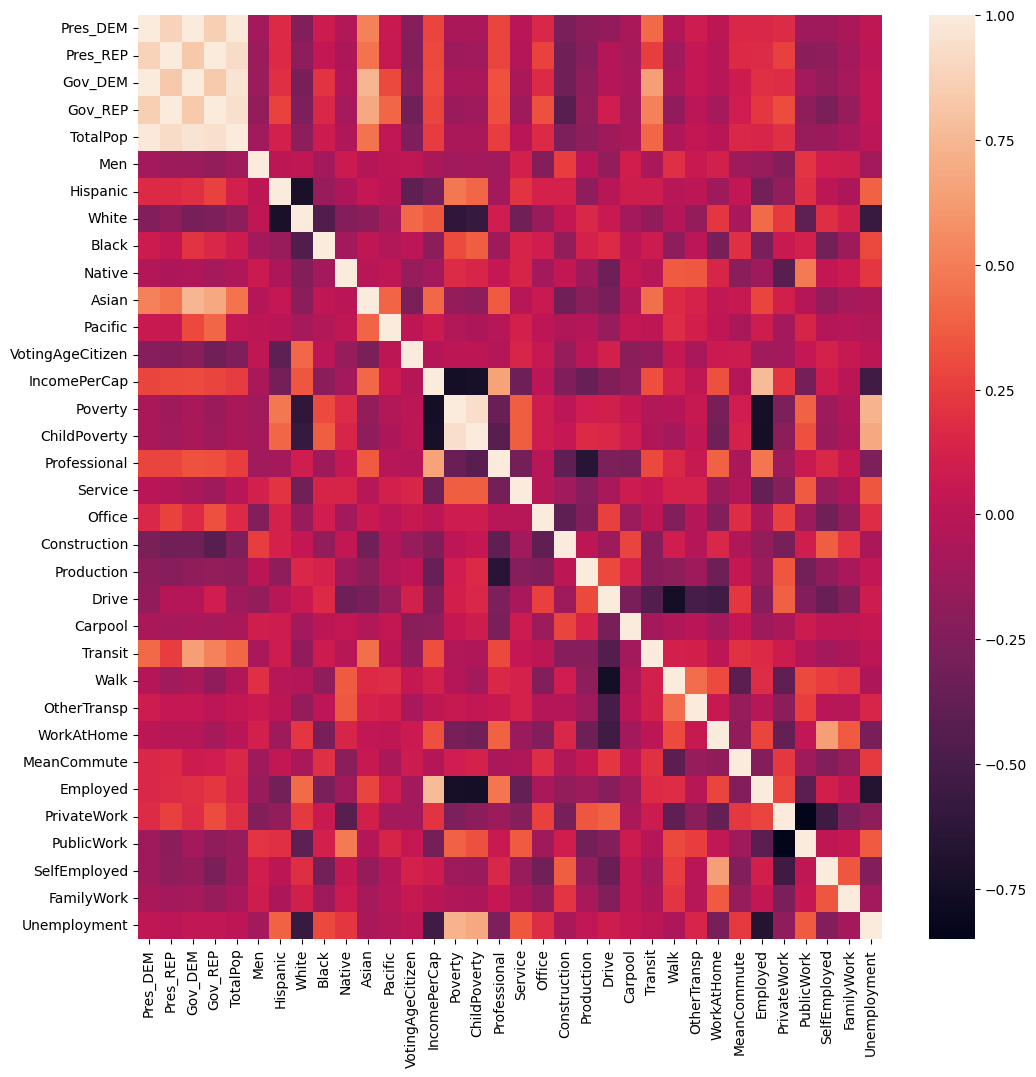

In [40]:
# normalize된 데이터로 다시 correaction 확인
plt.figure(figsize=(12,12))
sns.heatmap(df.corr())


<Axes: >

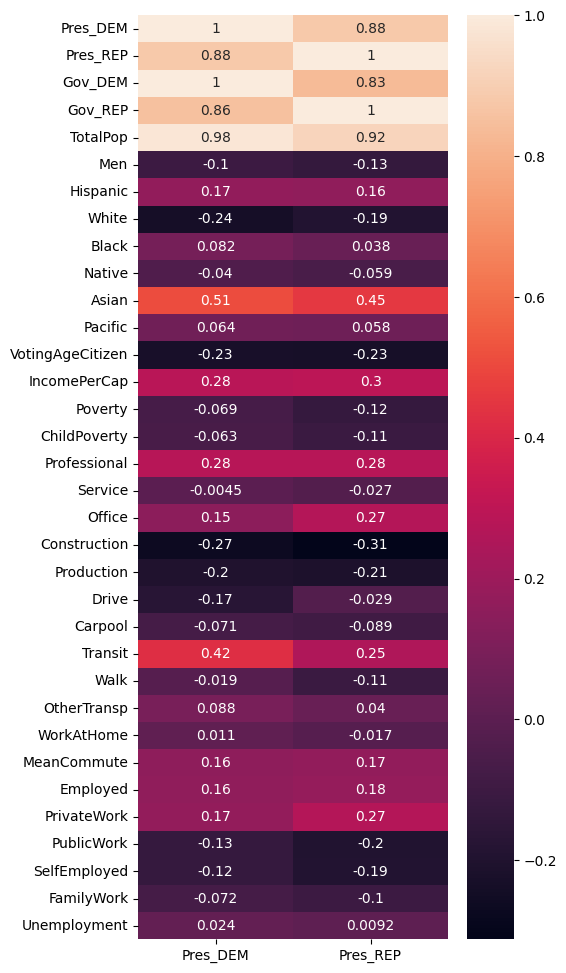

In [41]:
plt.figure(figsize=(5,12))
sns.heatmap(df.corr()[['Pres_DEM','Pres_REP']],annot=True)

In [42]:
df_norm = df.copy()

In [43]:
df_norm['Pres_DEM']/=df['Pres_DEM'] +df['Pres_REP']
df_norm['Pres_REP']/=df['Pres_DEM'] +df['Pres_REP']
df_norm['Gov_DEM']/=df['Gov_DEM'] +df['Gov_REP']
df_norm['Gov_REP']/=df['Gov_DEM'] +df['Gov_REP']

<Axes: >

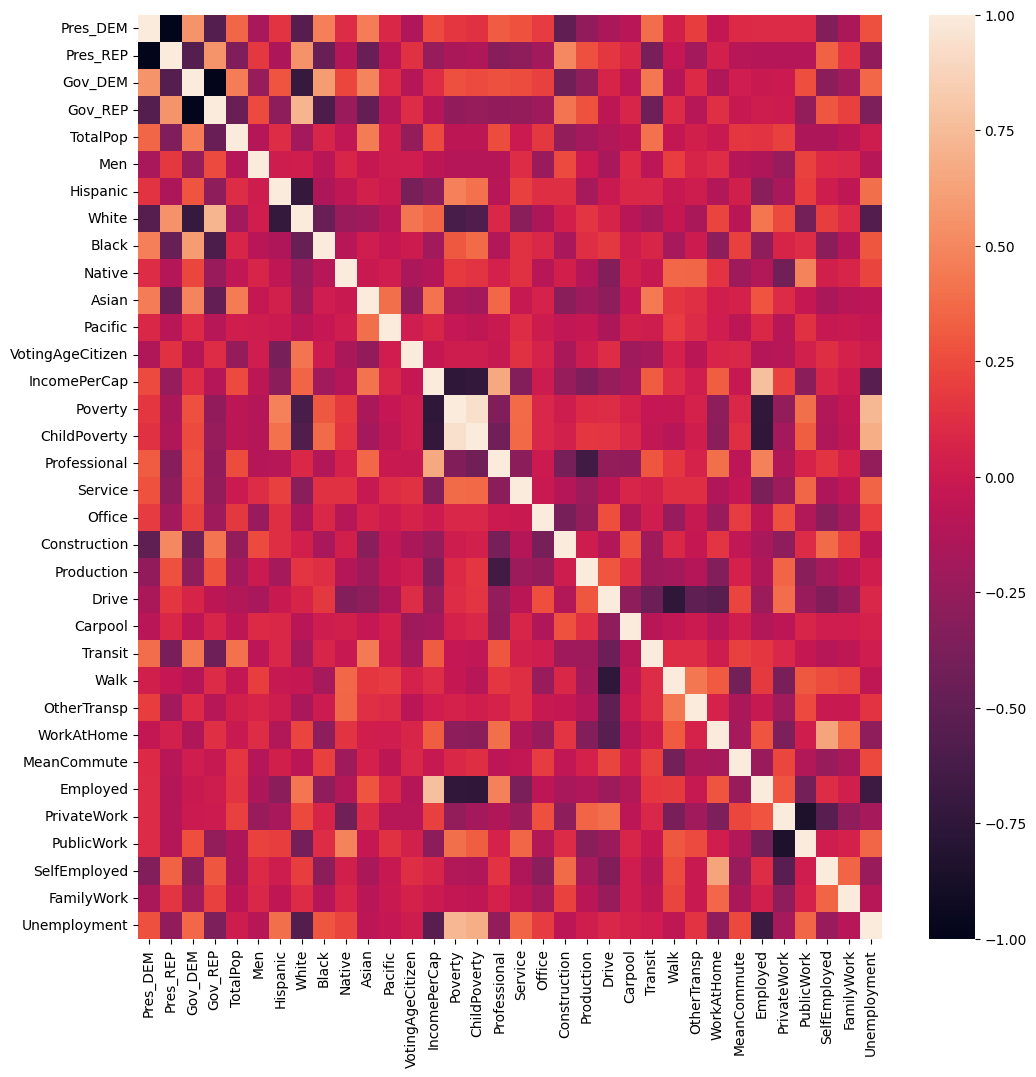

In [46]:
plt.figure(figsize=(12,12))
sns.heatmap(df_norm.corr())


<Axes: >

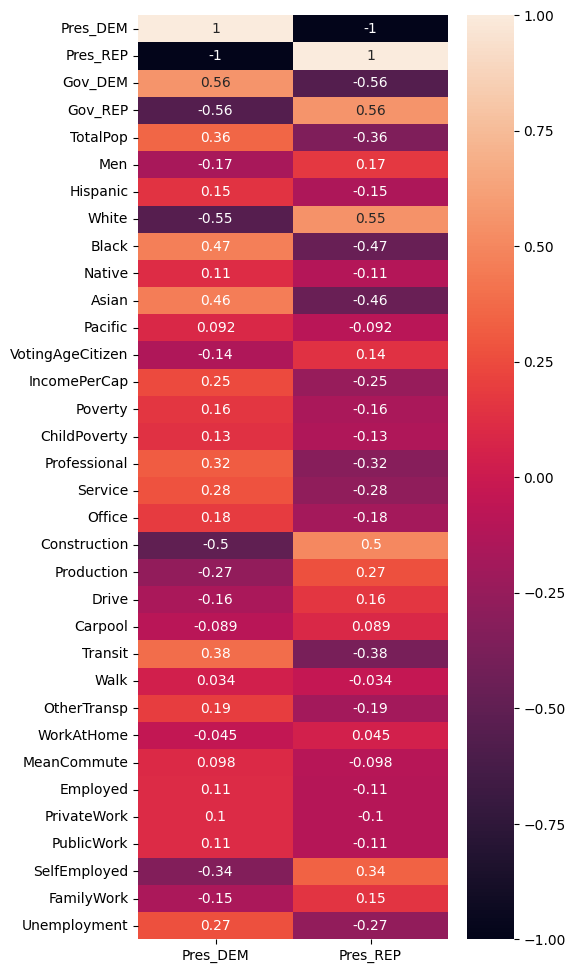

In [47]:
plt.figure(figsize=(5,12))
sns.heatmap(df_norm.corr()[['Pres_DEM','Pres_REP']],annot=True)

### 문제 8. Seaborn을 이용하여 연관성 높은 데이터의 Jointplot 확인

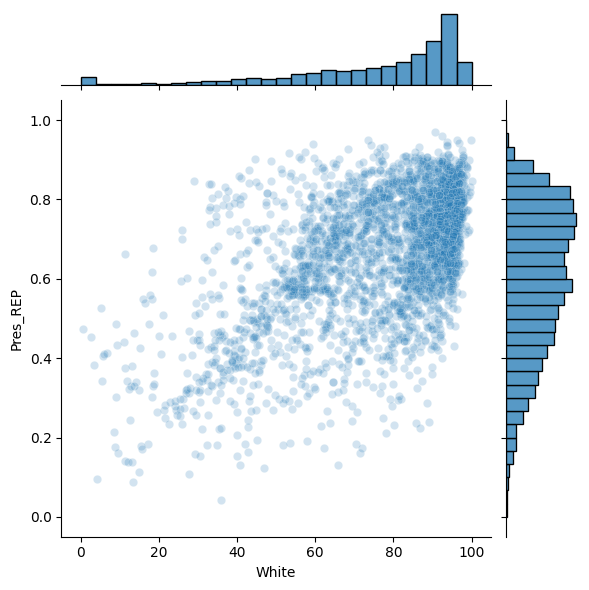

In [54]:
sns.jointplot(x='White',y='Pres_REP',data=df_norm,alpha=0.2)

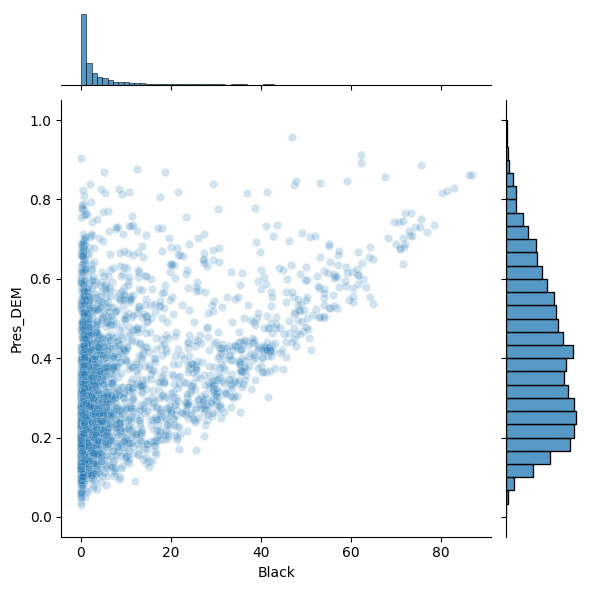

In [56]:
sns.jointplot(x='Black',y='Pres_DEM',data=df_norm,alpha=0.2)

## Step 3. Plotly를 이용하여 데이터 시각화하기


### 문제 9. Plotly의 Choropleth 데이터 포맷으로 맞추기

In [ ]:
import plotly.figure_factory as ff

# FIPS 코드 불러오기
df_sample = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/laucnty16.csv')
df_sample['State FIPS Code'] = df_sample['State FIPS Code'].apply(lambda x: str(x).zfill(2))
df_sample['County FIPS Code'] = df_sample['County FIPS Code'].apply(lambda x: str(x).zfill(3))
df_sample['FIPS'] = df_sample['State FIPS Code'] + df_sample['County FIPS Code']

# Color Scale 세팅
colorscale = ["#f7fbff","#ebf3fb","#deebf7","#d2e3f3","#c6dbef","#b3d2e9","#9ecae1",
              "#85bcdb","#6baed6","#57a0ce","#4292c6","#3082be","#2171b5","#1361a9",
              "#08519c","#0b4083","#08306b"]

In [ ]:
# ff.create_choropleth()에서 사용할 수 있도록 데이터프레임 정리하기
# Hint) 공식 레퍼런스 참조: https://plotly.com/python/county-choropleth/#the-entire-usa








### 문제 10. Choropleth map 시각화하기

In [ ]:
# ff.create_choropleth() 메소드를 이용하여 Choropleth 플랏하기
# Hint) 공식 레퍼런스 참조: https://plotly.com/python/county-choropleth/#the-entire-usa

fig = ff.create_choropleth(...)



fig.layout.template = None
fig.show()

## Step 4. 모델 학습을 위한 데이터 전처리

### 문제 11. 학습을 위한 데이터프레임 구성하기

In [ ]:
# 투표 결과에 해당하는 데이터는 입력 데이터에서 제거한다.
# 예측 타겟은 DEM vs. REP 투표 비율로 한다.

X =
y =

### 문제 12. StandardScaler를 이용해 수치형 데이터 표준화하기


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# StandardScaler를 이용해 수치형 데이터를 표준화하기
scaler =
X =



### 문제 13. 학습데이터와 테스트데이터 분리하기


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# train_test_split() 함수로 학습 데이터와 테스트 데이터 분리하기
X_train, X_test, y_train, y_test =

### 문제 14. PCA를 이용해 데이터 전처리 수행하기

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
# PCA를 이용해 Dimensionality Reduction 수행하기
pca =






## Step 4. Regression 모델 학습하기

### 문제 15. LightGBM Regression 모델 학습하기

In [ ]:
from lightgbm import LGBMRegressor

In [ ]:
# XGBRegressor 모델 생성/학습. Feature에 PCA 적용하기
model_reg =




### 문제 16. Regression 모델 정확도 출력하기

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report
from math import sqrt

In [ ]:
# Predict를 수행하고 mean_absolute_error, mean_squared_error, classification_report 결과 출력하기
pred =





## Step 5. Classification 모델 학습하기


### 문제 17. XGBoost 모델 생성/학습하기


In [ ]:
from xgboost import XGBClassifier

In [ ]:
# XGBClassifier 모델 생성/학습
model_cls =





### 문제 18. Classifier의 Feature Importance 시각화하기


In [ ]:
# XGBClassifier 모델의 feature_importances_ 속성 시각화





### 문제 19. Classifier 모델 정확도 출력하기

In [ ]:
# Predict를 수행하고 classification_report() 결과 출력하기
pred =



